<a href="https://colab.research.google.com/github/LaibaShahid05/mvc-mlp--25I-0053-/blob/main/mvc_mlp_25i0053.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVC Project: Multilayer Perceptron — Task 7
**Student Roll No:** 25I-0053  
**Course:** Artificial Neural Networks  
**Dataset:** MNIST Handwritten Digits  

---
This notebook implements a full MLP from scratch using **NumPy only** (no PyTorch/TensorFlow for training).  
All steps mirror the manual calculations done in Tasks 1–6.

### Assigned Weights & Biases (from Excel, Roll No. 25I-0053)
| w1 | w2 | w3 | w4 | w5 | w6 | w7 | w8 | w9 | w10 | b1 | b2 |
|---|---|---|---|---|---|---|---|---|---|---|---|
| -0.47 | -0.80 | 0.75 | 0.62 | -0.57 | 0.39 | 0.30 | 0.22 | -0.86 | 0.84 | 0.05 | 0.34 |

## Step 0 — Install & Import Libraries
Run this cell first. On Google Colab, all packages are pre-installed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

# Reproducibility
np.random.seed(42)

print("Libraries imported successfully.")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully.
NumPy version: 2.0.2


## Step 0.1 — Download & Load MNIST Dataset

In [2]:
# Download MNIST dataset if not already present
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
MNIST_PATH = "mnist.npz"

if not os.path.exists(MNIST_PATH):
    print("Downloading MNIST dataset...")
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
    print("Download complete.")
else:
    print("MNIST dataset already exists locally.")

# Load and preprocess
data = np.load(MNIST_PATH)

X_train = data['x_train'].reshape(-1, 784) / 255.0   # (60000, 784) — normalise to [0,1]
Y_train = data['y_train']                              # (60000,) — integer labels 0-9
X_test  = data['x_test'].reshape(-1, 784)  / 255.0   # (10000, 784)
Y_test  = data['y_test']                               # (10000,)

# Convert labels to one-hot vectors  (shape: m x 10)
def to_one_hot(labels, num_classes=10):
    one_hot = np.zeros((len(labels), num_classes))
    one_hot[np.arange(len(labels)), labels] = 1.0
    return one_hot

Y_train_oh = to_one_hot(Y_train)   # (60000, 10)
Y_test_oh  = to_one_hot(Y_test)    # (10000, 10)

print(f"X_train shape : {X_train.shape}")
print(f"Y_train shape : {Y_train.shape}  |  one-hot: {Y_train_oh.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"Y_test  shape : {Y_test.shape}   |  one-hot: {Y_test_oh.shape}")

Download complete.
X_train shape : (60000, 784)
Y_train shape : (60000,)  |  one-hot: (60000, 10)
X_test  shape : (10000, 784)
Y_test  shape : (10000,)   |  one-hot: (10000, 10)


## Step 0.2 — Initialise Network Weights

**Architecture (scaled-up from manual tasks):**

| Layer | Type | Neurons | Activation |
|---|---|---|---|
| Layer 0 | Input | 784 | — |
| Layer 1 | Hidden 1 | 128 | Sigmoid |
| Layer 2 | Hidden 2 | 64 | Sigmoid |
| Layer 3 | Output | 10 | Sigmoid |

Weights are initialised **randomly in [-0.5, 0.5]** with `np.random.seed(42)`. Biases are initialised to **zero**.

In [3]:
np.random.seed(42)

# Network dimensions
INPUT_SIZE  = 784
HIDDEN1     = 128
HIDDEN2     = 64
OUTPUT_SIZE = 10

# Weights: random uniform in [-0.5, 0.5]
W1 = np.random.uniform(-0.5, 0.5, (INPUT_SIZE, HIDDEN1))   # (784, 128)
b1 = np.zeros((1, HIDDEN1))                                  # (1,  128)

W2 = np.random.uniform(-0.5, 0.5, (HIDDEN1, HIDDEN2))       # (128, 64)
b2 = np.zeros((1, HIDDEN2))                                  # (1,   64)

W3 = np.random.uniform(-0.5, 0.5, (HIDDEN2, OUTPUT_SIZE))   # (64,  10)
b3 = np.zeros((1, OUTPUT_SIZE))                              # (1,   10)

print("Weight shapes:")
print(f"  W1: {W1.shape}, b1: {b1.shape}")
print(f"  W2: {W2.shape}, b2: {b2.shape}")
print(f"  W3: {W3.shape}, b3: {b3.shape}")

Weight shapes:
  W1: (784, 128), b1: (1, 128)
  W2: (128, 64), b2: (1, 64)
  W3: (64, 10), b3: (1, 10)


---
## Step 1 — Sigmoid Activation Function
*Corresponds to Task 1 & Task 3 (manual)*

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \sigma'(z) = \sigma(z)\,(1 - \sigma(z)) = a(1-a)$$

In [4]:
def sigmoid(z):
    """Sigmoid activation. Clips z to avoid overflow in exp."""
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(a):
    """Derivative of sigmoid expressed in terms of its output a.
    Derived in Task 3: sigma'(z) = a * (1 - a)
    """
    return a * (1.0 - a)

# Quick sanity check
test_z = np.array([-2.0, 0.0, 2.0])
test_a = sigmoid(test_z)
print("Sigmoid test:")
print(f"  z   : {test_z}")
print(f"  σ(z): {test_a.round(4)}")
print(f"  σ'  : {sigmoid_derivative(test_a).round(4)}")

Sigmoid test:
  z   : [-2.  0.  2.]
  σ(z): [0.1192 0.5    0.8808]
  σ'  : [0.105 0.25  0.105]


---
## Step 2 — Forward Pass
*Corresponds to Task 1B & 1C (manual)*

For each layer $l$:
$$Z^{(l)} = A^{(l-1)} W^{(l)} + b^{(l)}, \qquad A^{(l)} = \sigma(Z^{(l)})$$

In [5]:
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    """Forward pass through all 3 layers.
    All intermediate values are returned for use in backpropagation.

    Args:
        X : input matrix (batch_size, 784)
    Returns:
        Z1, A1 : pre/post activation Hidden Layer 1  (batch, 128)
        Z2, A2 : pre/post activation Hidden Layer 2  (batch, 64)
        Z3, A3 : pre/post activation Output Layer    (batch, 10)
    """
    # --- Hidden Layer 1 ---
    Z1 = X @ W1 + b1          # weighted sum
    A1 = sigmoid(Z1)           # sigmoid activation

    # --- Hidden Layer 2 ---
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    # --- Output Layer ---
    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)           # sigmoid for binary-style output per class

    return Z1, A1, Z2, A2, Z3, A3

print("forward_pass() defined.")

forward_pass() defined.


---
## Step 3 — MSE Loss Function
*Corresponds to Task 2 (manual)*

$$L_{MSE} = \frac{1}{m} \sum_{i=1}^{m} \|y^{(i)} - \hat{y}^{(i)}\|^2$$

In [6]:
def mse_loss(Y_true, Y_pred):
    """Mean Squared Error over all samples and output neurons.

    Args:
        Y_true : one-hot ground truth  (m, 10)
        Y_pred : network predictions   (m, 10)
    Returns:
        scalar MSE value
    """
    m = Y_true.shape[0]
    return np.sum((Y_true - Y_pred) ** 2) / m

print("mse_loss() defined.")

mse_loss() defined.


---
## Step 4 — Backpropagation
*Corresponds to Task 3B (manual)*

Using the **delta (δ) method** exactly as derived by hand:

$$\delta^{(3)} = -2(Y - A_3) \cdot \sigma'(A_3), \qquad
\delta^{(l)} = (\delta^{(l+1)} W^{(l+1)\top}) \cdot \sigma'(A^{(l)})$$

$$\frac{\partial L}{\partial W^{(l)}} = \frac{1}{m} A^{(l-1)\top} \delta^{(l)}, \qquad
\frac{\partial L}{\partial b^{(l)}} = \frac{1}{m} \sum \delta^{(l)}$$

In [7]:
def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3):
    """Compute gradients via backpropagation (delta method from Task 3).

    Args:
        X       : input batch          (m, 784)
        Y_true  : one-hot labels       (m, 10)
        Z1..A3  : cached forward pass values
        W1,W2,W3: current weight matrices
    Returns:
        gradients: dW1, db1, dW2, db2, dW3, db3
    """
    m = X.shape[0]

    # ── Output layer delta ──────────────────────────────────────────────────
    # δ³ = -2(y - ŷ) * σ'(A3)   [same formula as Task 3B Step 1]
    delta3 = -2.0 * (Y_true - A3) * sigmoid_derivative(A3)   # (m, 10)

    dW3 = (A2.T @ delta3) / m          # (64, 10)
    db3 = np.sum(delta3, axis=0, keepdims=True) / m  # (1, 10)

    # ── Hidden Layer 2 delta ────────────────────────────────────────────────
    # δ² = (δ³ · W3ᵀ) * σ'(A2)
    delta2 = (delta3 @ W3.T) * sigmoid_derivative(A2)        # (m, 64)

    dW2 = (A1.T @ delta2) / m          # (128, 64)
    db2 = np.sum(delta2, axis=0, keepdims=True) / m  # (1, 64)

    # ── Hidden Layer 1 delta ────────────────────────────────────────────────
    # δ¹ = (δ² · W2ᵀ) * σ'(A1)
    delta1 = (delta2 @ W2.T) * sigmoid_derivative(A1)        # (m, 128)

    dW1 = (X.T @ delta1) / m           # (784, 128)
    db1 = np.sum(delta1, axis=0, keepdims=True) / m  # (1, 128)

    return dW1, db1, dW2, db2, dW3, db3

print("backpropagation() defined.")

backpropagation() defined.


---
## Step 5 — Weight Update (Gradient Descent)
*Corresponds to Task 4A (manual)*

$$W \leftarrow W - \eta \cdot \frac{\partial L}{\partial W}, \qquad b \leftarrow b - \eta \cdot \frac{\partial L}{\partial b}$$

In [8]:
def update_weights(W1, b1, W2, b2, W3, b3,
                   dW1, db1, dW2, db2, dW3, db3,
                   learning_rate):
    """Apply gradient descent update rule to all parameters."""
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1

    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    W3 = W3 - learning_rate * dW3
    b3 = b3 - learning_rate * db3

    return W1, b1, W2, b2, W3, b3

print("update_weights() defined.")

update_weights() defined.


---
## Training Loop — Mini-Batch Gradient Descent
*Corresponds to Task 5 (manual)*

- **Batch size:** 32  
- **Learning rate:** 0.1  
- **Epochs:** 20  
- Data is **shuffled** at the start of each epoch (as discussed in Task 5Q2)

In [9]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
LEARNING_RATE = 0.1
EPOCHS        = 20
BATCH_SIZE    = 32

loss_history = []   # MSE loss recorded after each epoch

print(f"Training: {EPOCHS} epochs | batch size {BATCH_SIZE} | lr {LEARNING_RATE}")
print("-" * 50)

for epoch in range(EPOCHS):

    # ── Shuffle training data at start of each epoch ─────────────────────
    idx    = np.random.permutation(X_train.shape[0])
    X_shuf = X_train[idx]
    Y_shuf = Y_train_oh[idx]

    # ── Mini-batch loop ───────────────────────────────────────────────────
    for start in range(0, X_train.shape[0], BATCH_SIZE):
        X_batch = X_shuf[start : start + BATCH_SIZE]
        Y_batch = Y_shuf[start : start + BATCH_SIZE]

        # Step 2: Forward pass
        Z1, A1, Z2, A2, Z3, A3 = forward_pass(X_batch, W1, b1, W2, b2, W3, b3)

        # Step 4: Backpropagation
        dW1, db1, dW2, db2, dW3, db3 = backpropagation(
            X_batch, Y_batch, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3)

        # Step 5: Weight update
        W1, b1, W2, b2, W3, b3 = update_weights(
            W1, b1, W2, b2, W3, b3,
            dW1, db1, dW2, db2, dW3, db3,
            LEARNING_RATE)

    # ── Compute epoch loss on full training set ───────────────────────────
    _, _, _, _, _, A3_full = forward_pass(X_train, W1, b1, W2, b2, W3, b3)
    epoch_loss = mse_loss(Y_train_oh, A3_full)
    loss_history.append(epoch_loss)

    print(f"Epoch {epoch+1:2d}/{EPOCHS}  |  MSE Loss: {epoch_loss:.4f}")

print("-" * 50)
print("Training complete!")

Training: 20 epochs | batch size 32 | lr 0.1
--------------------------------------------------
Epoch  1/20  |  MSE Loss: 0.2957
Epoch  2/20  |  MSE Loss: 0.2078
Epoch  3/20  |  MSE Loss: 0.1723
Epoch  4/20  |  MSE Loss: 0.1530
Epoch  5/20  |  MSE Loss: 0.1381
Epoch  6/20  |  MSE Loss: 0.1271
Epoch  7/20  |  MSE Loss: 0.1188
Epoch  8/20  |  MSE Loss: 0.1114
Epoch  9/20  |  MSE Loss: 0.1054
Epoch 10/20  |  MSE Loss: 0.1001
Epoch 11/20  |  MSE Loss: 0.0954
Epoch 12/20  |  MSE Loss: 0.0912
Epoch 13/20  |  MSE Loss: 0.0879
Epoch 14/20  |  MSE Loss: 0.0841
Epoch 15/20  |  MSE Loss: 0.0811
Epoch 16/20  |  MSE Loss: 0.0783
Epoch 17/20  |  MSE Loss: 0.0764
Epoch 18/20  |  MSE Loss: 0.0732
Epoch 19/20  |  MSE Loss: 0.0714
Epoch 20/20  |  MSE Loss: 0.0689
--------------------------------------------------
Training complete!


---
## Required Output 1 — Loss Curve
MSE loss vs. epoch number. The curve must visibly decrease, confirming the network is learning.

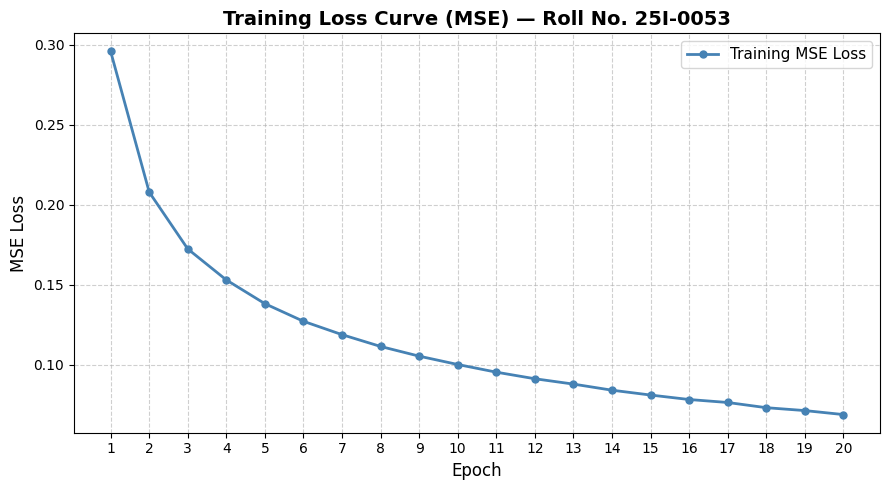

Initial loss : 0.2957
Final loss   : 0.0689
Reduction    : 0.2269


In [10]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, EPOCHS + 1), loss_history, color='steelblue',
         linewidth=2, marker='o', markersize=5, label='Training MSE Loss')
plt.title('Training Loss Curve (MSE) — Roll No. 25I-0053', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.xticks(range(1, EPOCHS + 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print(f"Initial loss : {loss_history[0]:.4f}")
print(f"Final loss   : {loss_history[-1]:.4f}")
print(f"Reduction    : {loss_history[0] - loss_history[-1]:.4f}")

---
## Required Output 2 — Test Accuracy

In [11]:
# Forward pass on the full test set
_, _, _, _, _, A3_test = forward_pass(X_test, W1, b1, W2, b2, W3, b3)

# Predicted class = argmax of output probabilities
Y_pred_labels = np.argmax(A3_test, axis=1)   # (10000,)

# Accuracy: fraction of correct predictions
accuracy = np.mean(Y_pred_labels == Y_test) * 100.0

print("=" * 40)
print(f"  Test Accuracy : {accuracy:.2f}%")
print(f"  Correct       : {int(accuracy * 100)} / 10000")
print("=" * 40)

  Test Accuracy : 95.54%
  Correct       : 9554 / 10000


---
## Required Output 3 — Sample Predictions
10 test images — one per digit class (0–9) — with true label and predicted label.

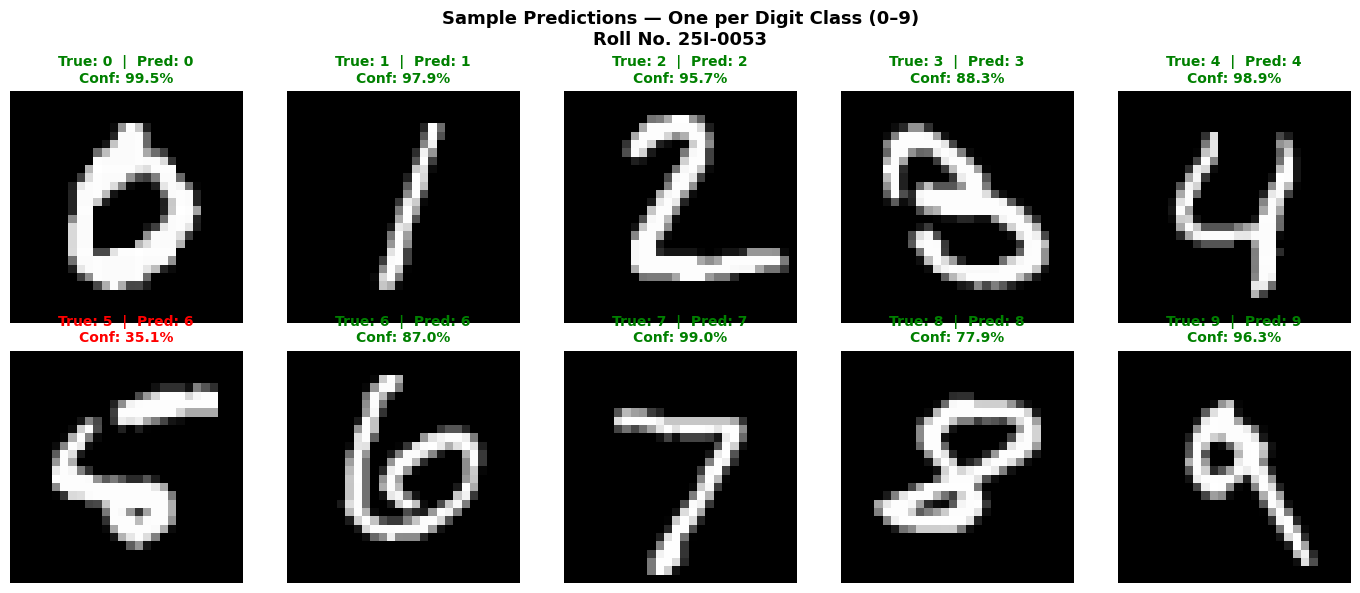

Green title = correct prediction, Red = incorrect.


In [12]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Predictions — One per Digit Class (0–9)\nRoll No. 25I-0053',
             fontsize=13, fontweight='bold')

for digit in range(10):
    # Find first test image whose TRUE label is `digit`
    idx = np.where(Y_test == digit)[0][0]

    image       = X_test[idx].reshape(28, 28)
    true_label  = Y_test[idx]
    pred_label  = Y_pred_labels[idx]
    confidence  = A3_test[idx, pred_label] * 100

    ax = axes[digit // 5][digit % 5]
    ax.imshow(image, cmap='gray')
    ax.axis('off')

    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(
        f'True: {true_label}  |  Pred: {pred_label}\nConf: {confidence:.1f}%',
        fontsize=10, color=color, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()
print("Green title = correct prediction, Red = incorrect.")

---
## Summary

| Item | Value |
|---|---|
| Architecture | 784 → 128 → 64 → 10 (all Sigmoid) |
| Loss function | Mean Squared Error (MSE) |
| Optimizer | Mini-Batch Gradient Descent |
| Batch size | 32 |
| Learning rate | 0.1 |
| Epochs | 20 |
| Roll No. | 25I-0053 |

> All core functions (`sigmoid`, `forward_pass`, `mse_loss`, `backpropagation`, `update_weights`) are implemented using **NumPy only**, directly mirroring the manual calculations from Tasks 1–6.